<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2010/week10_video3_autocorrelations_filled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# [statsmodels](https://www.statsmodels.org/stable/index.html),  [datasets](https://www.statsmodels.org/stable/datasets/index.html#datasets)

# Create a stationary time series

In [2]:
import statsmodels.tsa.arima_process as arima_process

In [7]:
process = arima_process.ArmaProcess(ar=[1,-0.8], ma=[1])


In [6]:
process

ArmaProcess([1.0, -0.8], [1.0], nobs=100) at 0x7ac347ac34a0

## Take a sample

In [22]:
z = process.generate_sample(nsample=100)
z

array([ 0.20472421, -0.19313799, -1.12984139, -1.24592202, -1.80872093,
       -2.35909616, -2.23602498, -2.7275082 , -2.73790292, -0.94975679,
        1.00167561,  1.60692695,  0.08533556,  2.35212681,  3.94669881,
        2.43666649,  3.0825395 ,  1.58867023,  1.16710114,  0.62267692,
        1.07864732,  0.33021423,  1.36540221, -0.36387048, -0.89902996,
       -0.22878059, -0.65196095, -0.28327974, -0.42939041, -1.56871735,
       -0.33463153,  0.3832514 , -1.06057255, -0.16230337, -0.36787665,
        0.82055891, -0.29843594, -1.40913994, -1.41901365, -1.85236037,
       -2.2265648 , -0.30645382,  0.11416447, -0.76367119, -0.45605745,
       -0.3886217 ,  0.22166583,  0.39169025,  0.52418771, -0.20442493,
        0.0381321 , -0.73190906, -0.34064596, -0.50674752,  0.69172525,
        0.4577897 , -1.36226696, -1.2387315 ,  0.08132115,  0.26456258,
       -0.80100389, -1.12296833, -1.30767923, -1.88777113, -0.02542866,
       -0.40049491, -0.51245589,  1.37308488,  0.64277727, -0.32

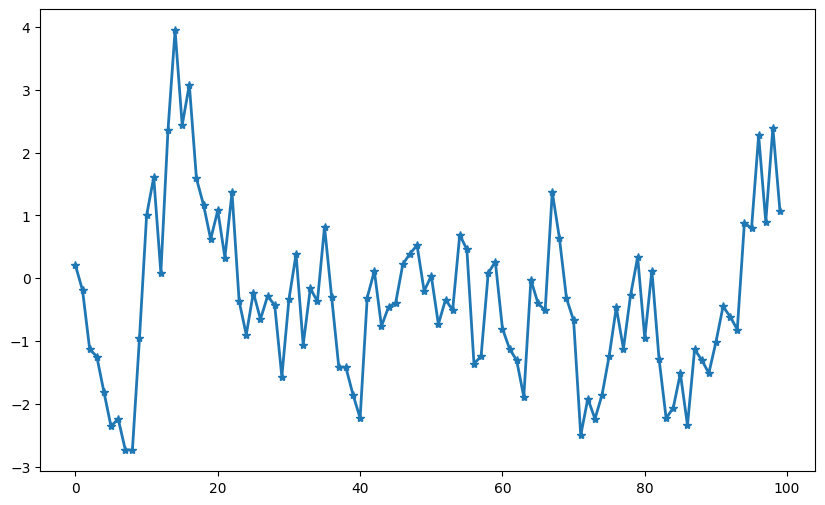

In [23]:
plt.figure(figsize=(10,6))
plt.plot(z, linewidth=2, marker='*')


# Plotting autocorrelations (These are theoretical AC on the process and pass in the number of lags)

In [25]:
acf = process.acf(lags=20)
acf

#Autocorrelation: This measures the correlation between a time series and a lagged version of itself. In simpler terms, it tells you how much an observation at time t is related to an observation at time t-k (where k is the lag).
#Lag: When you specify lags=20 (as in acf = process.acf(lags=20)), you are asking the function to calculate the autocorrelation for various time differences, specifically for k = 1, 2, 3, ..., 20.
#Lag 20: Measures the correlation between y_t and y_{t-20}.

array([1.        , 0.8       , 0.64      , 0.512     , 0.4096    ,
       0.32768   , 0.262144  , 0.2097152 , 0.16777216, 0.13421773,
       0.10737418, 0.08589935, 0.06871948, 0.05497558, 0.04398047,
       0.03518437, 0.0281475 , 0.022518  , 0.0180144 , 0.01441152])

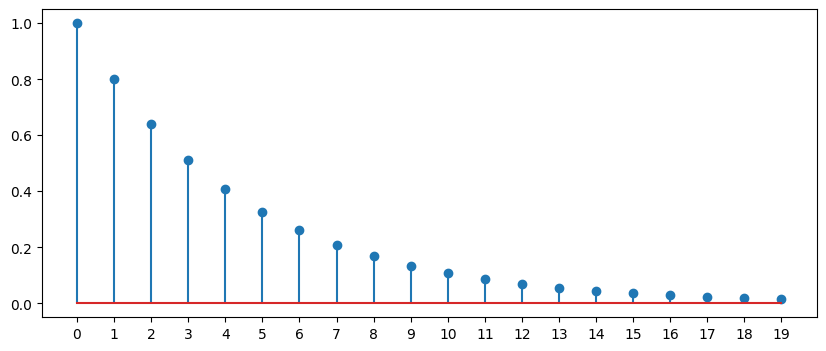

In [26]:
plt.figure(figsize=(10,4))
plt.stem(acf)
plt.xticks(ticks=range(0,20,1))
plt.show()


# Plotting sample autocorrelations

In [ ]:
import statsmodels.graphics.tsaplots as tsaplots

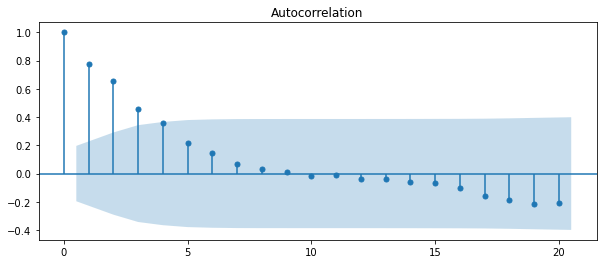

In [ ]:
_, ax = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(z,lags=20, ax=ax)
plt.show()

# Load sunspots data

In [ ]:
sunspots = pd.read_csv('Sunspots.csv')
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [ ]:
sunspots.loc[0,'Date']

'1749-01-31'

In [ ]:
pd.to_datetime(sunspots.loc[0,'Date'])

Timestamp('1749-01-31 00:00:00')

In [ ]:
sunspots = sunspots.set_index(pd.to_datetime(sunspots['Date']))
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
Date,,,
1749-01-31,0,1749-01-31,96.7
1749-02-28,1,1749-02-28,104.3
1749-03-31,2,1749-03-31,116.7
1749-04-30,3,1749-04-30,92.8
1749-05-31,4,1749-05-31,141.7


In [ ]:
sunspots.drop(columns=['Unnamed: 0','Date'], inplace=True)

In [ ]:
sunspots.rename(columns={'Monthly Mean Total Sunspot Number':'values'}, inplace=True)

<AxesSubplot:xlabel='Date'>

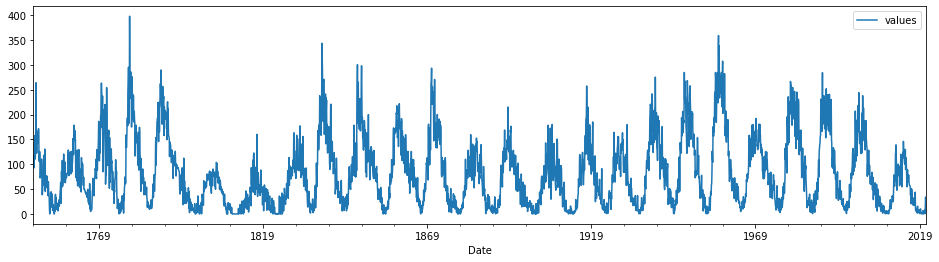

In [ ]:
sunspots.plot(figsize=(16,4))

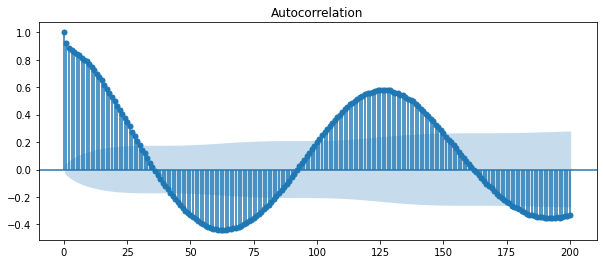

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(sunspots,lags=200, ax=ax)
plt.show()

# Take a difference

In [ ]:
diff_sunspots = sunspots.diff().dropna()

<AxesSubplot:xlabel='Date'>

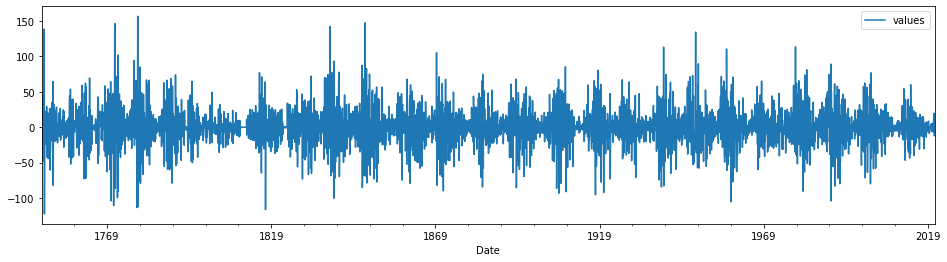

In [ ]:
diff_sunspots.plot(figsize=(16,4))

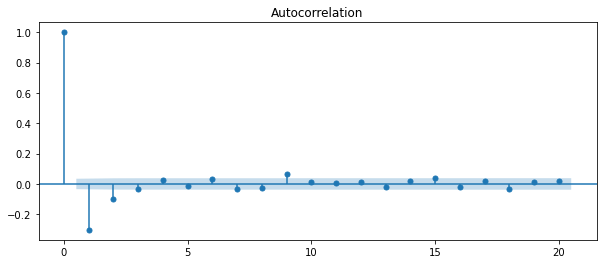

In [ ]:
_, ax = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(diff_sunspots,lags=20, ax=ax)
plt.show()